✅** TA1: Stock Price Prediction using LSTM (RNN)**

👤 Name: Piyushkumar Ghate

🟦 🔹 Introduction

Stock price prediction is a time-series forecasting problem. In this assignment, we use a Recurrent Neural Network (RNN) with LSTM units to predict future stock prices.

LSTM networks are effective because they can remember long-term dependencies in sequential data.

🟦 🔹 Objective
Preprocess stock price dataset
Build an LSTM model
Train and evaluate the model
Predict future stock prices

1. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


2. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

3. Load Dataset

In [ ]:
file_path = "/content/drive/MyDrive/Colab Notebooks/all_stocks_5yr.csv"

df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (619040, 7)


,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL


4. Select Company Data

In [ ]:
company = "AAPL"

df = df[df['Name'] == company]

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

data = df[['date', 'close']]
data.set_index('date', inplace=True)

data.head()

,close
date,
2013-02-08,67.8542
2013-02-11,68.5614
2013-02-12,66.8428
2013-02-13,66.7156
2013-02-14,66.6556


5. Data Visualization

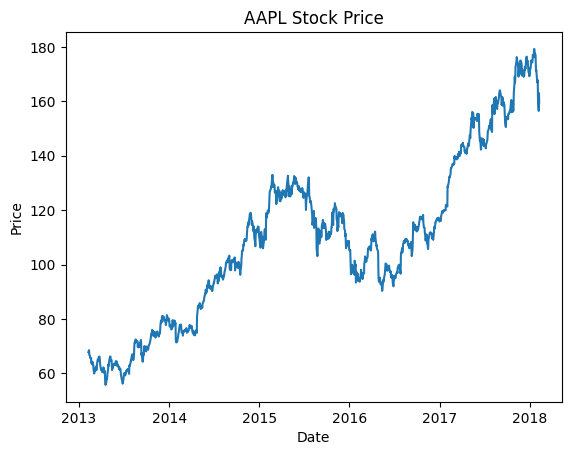

In [ ]:
plt.figure()
plt.plot(data['close'])
plt.title(f"{company} Stock Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

6. Data Normalization

In [ ]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

7. Sequence Creation

In [ ]:
X = []
y = []

time_step = 60

for i in range(time_step, len(scaled_data)):
    X.append(scaled_data[i-time_step:i, 0])
    y.append(scaled_data[i, 0])

X, y = np.array(X), np.array(y)

X = X.reshape(X.shape[0], X.shape[1], 1)

8. Train-Test Split

In [ ]:
split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

9. Build LSTM Model

In [ ]:
model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(X.shape[1],1)))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10. Train Model

In [ ]:
model.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - loss: 0.0131
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0016
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 9.5232e-04
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 8.6220e-04
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - loss: 8.1867e-04
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 142ms/step - loss: 7.8957e-04
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - loss: 7.5132e-04
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 7.2174e-04
Epoch 9/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 6.9616e-04
Epoch 10/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - loss: 6.6565e-04


11. Prediction & Evaluation

In [ ]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_pred = scaler.inverse_transform(train_pred)
test_pred = scaler.inverse_transform(test_pred)

y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

mae = mean_absolute_error(y_test_actual, test_pred)
rmse = np.sqrt(mean_squared_error(y_test_actual, test_pred))

print("MAE:", mae)
print("RMSE:", rmse)

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
MAE: 3.866065320332845
RMSE: 4.870905923725785


12. Visualization

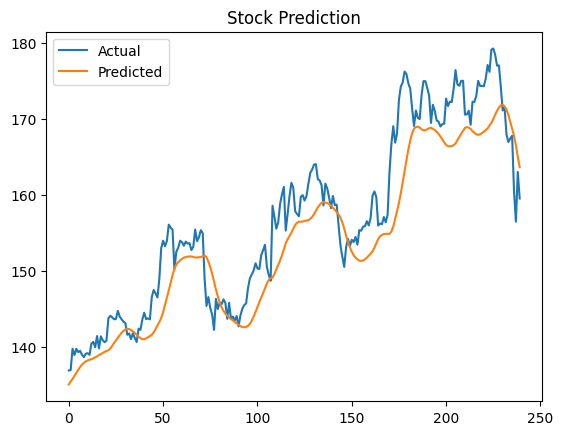

In [ ]:
plt.figure()
plt.plot(y_test_actual, label="Actual")
plt.plot(test_pred, label="Predicted")
plt.legend()
plt.title("Stock Prediction")
plt.show()

13. Future Prediction

In [ ]:
future_days = 30
last_data = scaled_data[-60:]

future_predictions = []

current_input = last_data.reshape(1, 60, 1)

for _ in range(future_days):
    next_pred = model.predict(current_input)[0][0]
    future_predictions.append(next_pred)
    current_input = np.append(current_input[:,1:,:], [[[next_pred]]], axis=1)

future_predictions = scaler.inverse_transform(np.array(future_predictions).reshape(-1,1))

print("Next 30 Days Prediction:")
print(future_predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━

Conclusion

The LSTM model successfully learned patterns in historical stock data and predicted future prices. This demonstrates the effectiveness of deep learning models for time-series forecasting.

####Github Link : https://github.com/itzzme77/ANNDL/blob/main/A25_TA_1.ipynb